In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# 1. 가상 데이터베이스(DB) 생성
np.random.seed(42)
n_samples = 100

temperature = np.random.uniform(300, 550, n_samples)
pressure = np.random.uniform(1.0, 3.0, n_samples)
gas_flow = np.random.uniform(50, 150, n_samples)
rf_power = np.random.uniform(100, 300, n_samples)
depo_time = np.random.uniform(30, 90, n_samples)

# 아레니우스 식 모사
R = 8.314
T_kelvin = temperature + 273.15
k = 1000 * np.exp(-40000 / (R * T_kelvin))

# 노이즈(실험 오차)를 추가해 실제 실험 데이터처럼 연출
noise = np.random.normal(0, 0.5, n_samples)
thickness = (k * depo_time * 0.1) + (pressure * 1.5) + (rf_power * 0.05) + noise
thickness = np.clip(thickness, 10, None)

In [3]:
# 데이터프레임 구축
db_dict = {
    'Temperature_C': round(pd.Series(temperature), 1),
    'Pressure_Torr': round(pd.Series(pressure), 2),
    'Gas_Flow_sccm': round(pd.Series(gas_flow), 1),
    'RF_Power_W': round(pd.Series(rf_power), 1),
    'Depo_Time_sec': round(pd.Series(depo_time), 1),
    'Thickness_nm': round(pd.Series(thickness), 2)
}
df = pd.DataFrame(db_dict)
df.to_csv('cvd_process_data.csv', index=False)
print("데이터셋 저장 완료")

데이터셋 저장 완료


In [4]:
# 2. 머신러닝 모델 학습
X = df[['Temperature_C', 'Pressure_Torr', 'Gas_Flow_sccm', 'RF_Power_W', 'Depo_Time_sec']]
y = df['Thickness_nm']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [7]:
# 3. 모델 예측 및 평가지표 계산
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("[모델 평가 결과]")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R² Score): {r2:.2f}")

[모델 평가 결과]
Mean Squared Error (MSE): 4.6723
R-squared (R² Score): 0.86


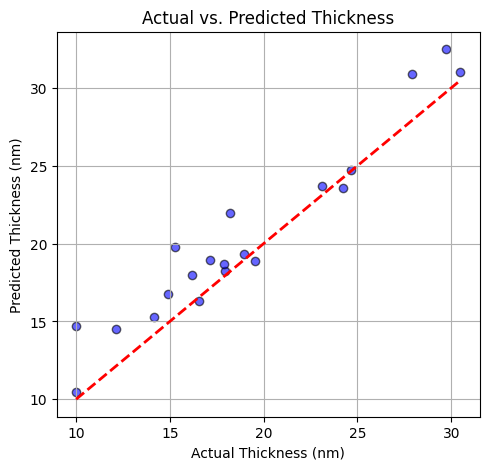

In [8]:
# 4. 시각화 1: 실제값 vs 예측값 비교
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Thickness')
plt.xlabel('Actual Thickness (nm)')
plt.ylabel('Predicted Thickness (nm)')
plt.grid(True)

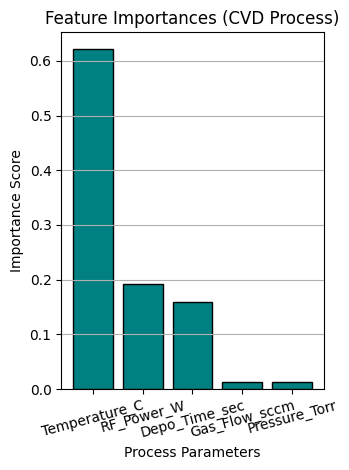

In [9]:
# 5. 시각화 2: 변수 중요도
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.subplot(1, 2, 2)
plt.title('Feature Importances (CVD Process)')
plt.bar(range(X.shape[1]), importances[indices], color='teal', align='center', edgecolor='k')
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=15)
plt.xlabel('Process Parameters')
plt.ylabel('Importance Score')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

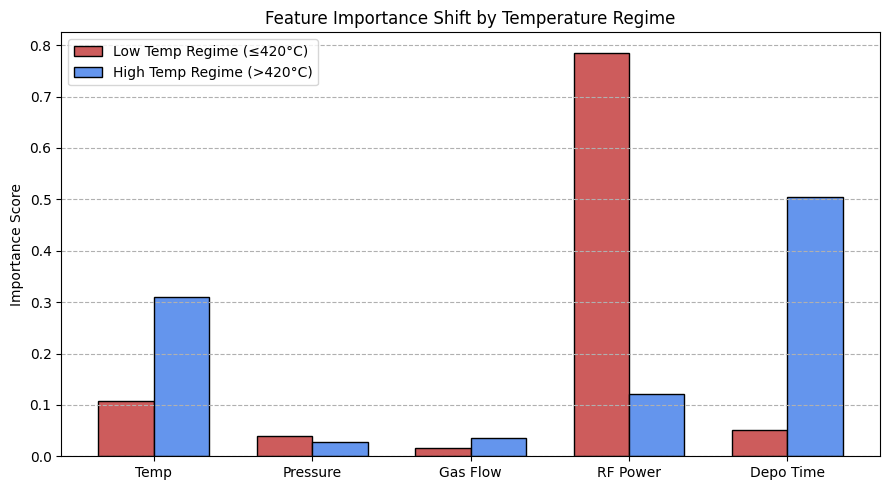

In [10]:
# 6. 온도 구간별 분석
df_low_T = df[df['Temperature_C'] <= 420]
df_high_T = df[df['Temperature_C'] > 420]

def get_feature_importance(sub_df):
    X_sub = sub_df[['Temperature_C', 'Pressure_Torr', 'Gas_Flow_sccm', 'RF_Power_W', 'Depo_Time_sec']]
    y_sub = sub_df['Thickness_nm']
    rf = RandomForestRegressor(n_estimators=50, random_state=42)
    rf.fit(X_sub, y_sub)
    return rf.feature_importances_

imp_low = get_feature_importance(df_low_T)
imp_high = get_feature_importance(df_high_T)

labels = ['Temp', 'Pressure', 'Gas Flow', 'RF Power', 'Depo Time']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, imp_low, width, label='Low Temp Regime (≤420°C)', color='indianred', edgecolor='k')
plt.bar(x + width/2, imp_high, width, label='High Temp Regime (>420°C)', color='cornflowerblue', edgecolor='k')
plt.ylabel('Importance Score')
plt.title('Feature Importance Shift by Temperature Regime')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()